In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from pathlib import Path
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

In [3]:
data_dir = Path("/Users/folasewaabdulsalam/Downloads/EEG_Based_Mental_Workload_Classifier/EEG-Based_Mental_Workload_Classifier/data")

channel_names = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']

sampling_frequency = 128

#intialize
all_data = []
all_subjects = []
all_workload = []

for file in sorted(data_dir.glob("*.txt")):
    filename = file.stem
    parts = filename.split("_")
    subject = parts[0]
    workload = parts[1]

    eeg_data = np.loadtxt(file)
    all_data.append(eeg_data)
    all_subjects.append(subject)
    all_workload.append(workload)
print(f"Successfully loaded {len(all_data)} files")

Successfully loaded 96 files


Creating RawArray with float64 data, n_channels=14, n_times=19200
    Range : 0 ... 19199 =      0.000 ...   149.992 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 423 samples (3.305 s)

The raw data shape: (19200, 14)
The filtered data shape: (19200, 14)


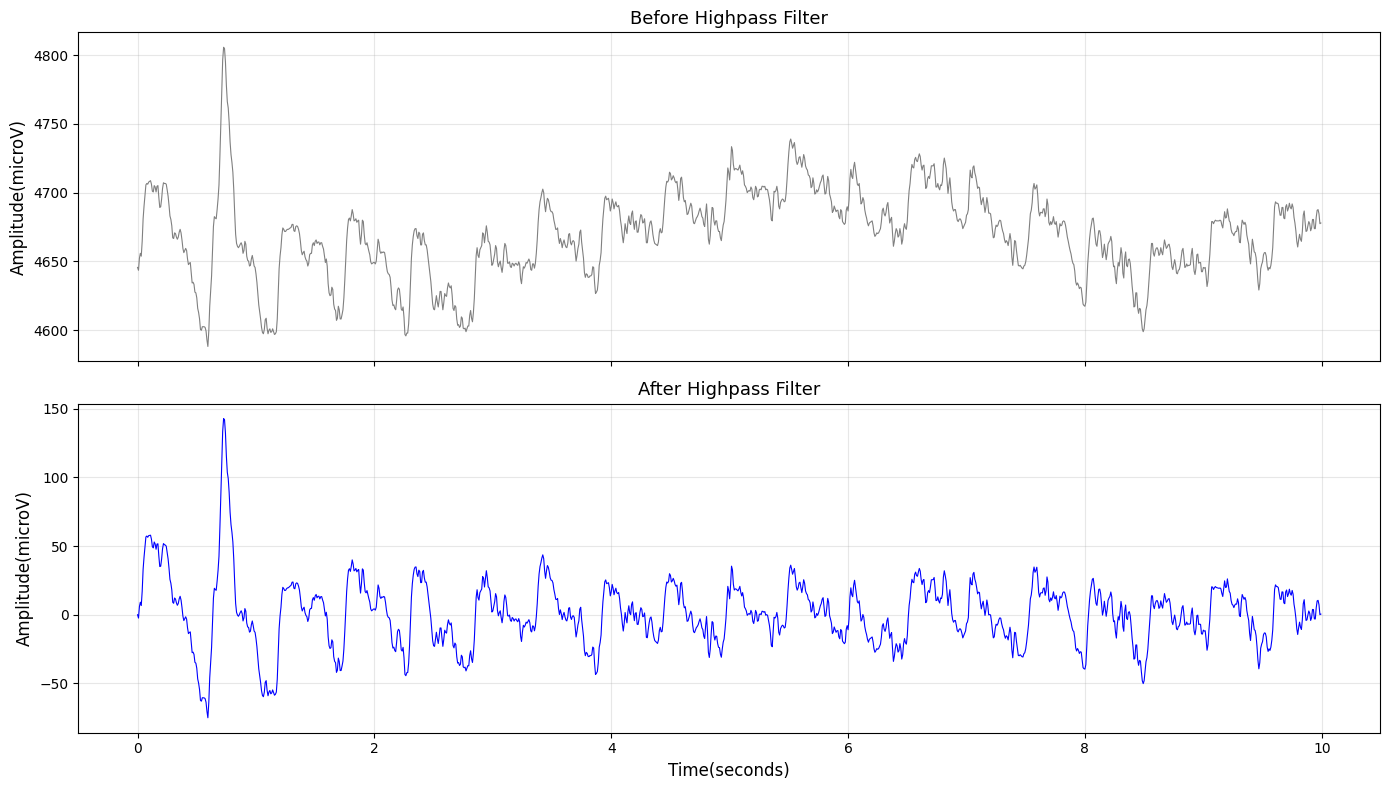

In [5]:
#preprocessing steps
#1. High pass filter at 1hz
#on first subject, low workload

sub01_lo_idx = None
sub01_hi_idx = None

for i in range(len(all_subjects)):
    if all_subjects[i] == 'sub01' and all_workload[i] == "lo":
        sub01_lo_idx = i
    if all_subjects[i] == 'sub01' and all_workload[i] == 'hi':
        sub01_hi_idx = i
sub01_lo = all_data[sub01_lo_idx]
sub01_hi = all_data[sub01_hi_idx]

#creating mne info
info = mne.create_info(ch_names = channel_names, sfreq=sampling_frequency, ch_types = 'eeg')
raw_sub01 = mne.io.RawArray(sub01_lo.T, info)

#applying the high-pass
filtered_raw_sub01 = raw_sub01.copy().filter(l_freq=1.0, h_freq=None)
filtered_sub01 = filtered_raw_sub01.get_data().T

print(f"The raw data shape: {sub01_lo.shape}")
print(f"The filtered data shape: {filtered_sub01.shape}")

#visualizing the efefct of high-pass filtering the data
duration = 10
samples = sampling_frequency * duration
time = np.arange(samples)/sampling_frequency

fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)

#before plotting
axes[0].plot(time, sub01_lo[:samples, 0], linewidth=0.8, color='gray')
axes[0].set_ylabel("Amplitude(microV)", fontsize=12)
axes[0].set_title("Before Highpass Filter", fontsize=13)
axes[0].grid(alpha=0.3)

axes[1].plot(time, filtered_sub01[:samples, 0], linewidth=0.8, color='blue')
axes[1].set_ylabel("Amplitude(microV)", fontsize=12)
axes[1].set_xlabel("Time(seconds)", fontsize=12)
axes[1].set_title("After Highpass Filter", fontsize=13)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

